In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [6, 3]
from tqdm import tqdm

from envs.linear_bandit import SimulatorTorchWrapper
from GreedyMLP import IncrementalGreedyAgent
from utils import sigmoid, softmax_torch, run_experiment_torch

# Linear reward

The reward score is linear in the context-action feature (as in the original paper):

$$P(y|x,a) = \frac{1}{1 + exp(-w_*^T \cdot [x,a])}$$

Important to note is that a noisy version of this formula implemented, i.e.,
$Y_{observed} = Ber\{p\}$, where $p = \frac{1}{1 + exp(-w_*^T \cdot [x,a] + \varepsilon)}$

In [2]:
np.random.seed(12)
k = 20
n = 10000

linear_env = SimulatorTorchWrapper(k=k, linear=True)
X = linear_env.generate_batch(n)
A = np.random.choice(range(k), size=n)
Y, true_scores = linear_env.generate_reward(A)

optimal_actions = true_scores.argmax(axis=1)
normalized_actions_scores = softmax_torch(true_scores).sum(axis=0)

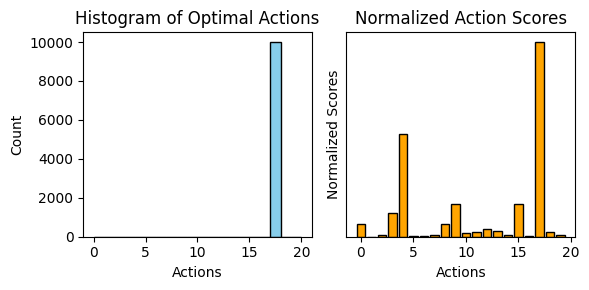

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].hist(optimal_actions, bins=range(0, k + 1), color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Optimal Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')

axes[1].bar(range(k), normalized_actions_scores, color='orange', edgecolor='black')
axes[1].set_title('Normalized Action Scores')
axes[1].set_xlabel('Actions')
axes[1].set_ylabel('Normalized Scores')
axes[1].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()

## Run single experiment 

In [4]:
batch_size = 32
n_iter = 10000

d = linear_env.d_x + linear_env.d_a
policy = IncrementalGreedyAgent(d)

chosen_actions, optimal_actions, logreg_regret, random_regret = run_experiment_torch(linear_env, policy, n_iter, batch_size, verbose=True)

      0/  10000 - mse params ------, mse scores: 5.2817, variance: ------
      1/  10000 - mse params ------, mse scores: 5.1191, variance: ------
      2/  10000 - mse params ------, mse scores: 5.9947, variance: ------
      3/  10000 - mse params ------, mse scores: 5.1043, variance: ------
      4/  10000 - mse params ------, mse scores: 4.5045, variance: ------
      5/  10000 - mse params ------, mse scores: 4.7601, variance: ------
      6/  10000 - mse params ------, mse scores: 4.6191, variance: ------
      7/  10000 - mse params ------, mse scores: 4.8990, variance: ------
      8/  10000 - mse params ------, mse scores: 4.5081, variance: ------
      9/  10000 - mse params ------, mse scores: 4.3008, variance: ------
     10/  10000 - mse params ------, mse scores: 4.3163, variance: ------
     11/  10000 - mse params ------, mse scores: 3.6698, variance: ------
     12/  10000 - mse params ------, mse scores: 3.8141, variance: ------
     13/  10000 - mse params ------, m

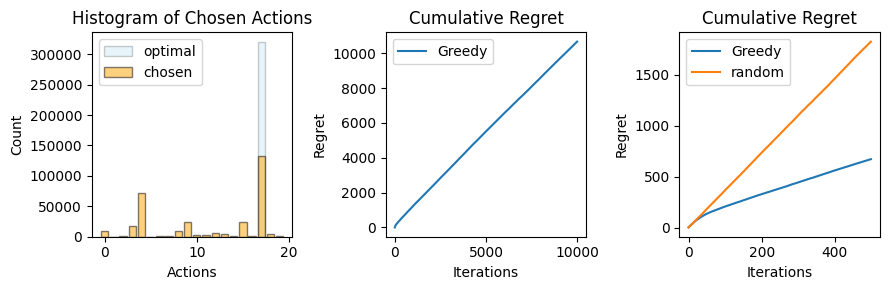

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)
axes[0].bar(range(k), optimal_actions, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), chosen_actions, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(np.array(logreg_regret).cumsum(), label='Greedy')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

# the same plot, but with random performance
axes[2].plot(np.array(logreg_regret)[:500].cumsum(), label='Greedy')
axes[2].plot(np.array(random_regret)[:500].cumsum(), label='random')
axes[2].set_title('Cumulative Regret')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Regret')
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
batch_size = 32
n_iter = 10000

d = linear_env.d_x + linear_env.d_a
params = {'temperature': 0.1}
policy = IncrementalGreedyAgent(d, params)

chosen_actions, optimal_actions, logreg_regret, random_regret = run_experiment_torch(linear_env, policy, n_iter, batch_size, verbose=True)

      0/  10000 - mse params ------, mse scores: 5.7410, variance: ------
      1/  10000 - mse params ------, mse scores: 5.5178, variance: ------
      2/  10000 - mse params ------, mse scores: 5.4358, variance: ------
      3/  10000 - mse params ------, mse scores: 5.2859, variance: ------
      4/  10000 - mse params ------, mse scores: 5.7349, variance: ------
      5/  10000 - mse params ------, mse scores: 4.5876, variance: ------
      6/  10000 - mse params ------, mse scores: 4.7191, variance: ------
      7/  10000 - mse params ------, mse scores: 4.3581, variance: ------
      8/  10000 - mse params ------, mse scores: 4.8607, variance: ------
      9/  10000 - mse params ------, mse scores: 4.5379, variance: ------
     10/  10000 - mse params ------, mse scores: 4.2763, variance: ------
     11/  10000 - mse params ------, mse scores: 4.0147, variance: ------
     12/  10000 - mse params ------, mse scores: 4.4384, variance: ------
     13/  10000 - mse params ------, m

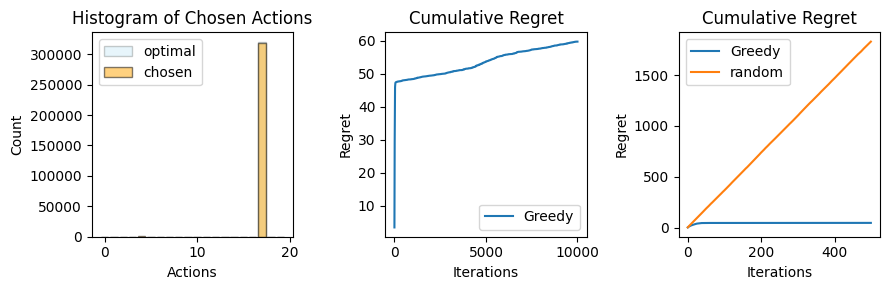

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)
axes[0].bar(range(k), optimal_actions, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), chosen_actions, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(np.array(logreg_regret).cumsum(), label='Greedy')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

# the same plot, but with random performance
axes[2].plot(np.array(logreg_regret)[:500].cumsum(), label='Greedy')
axes[2].plot(np.array(random_regret)[:500].cumsum(), label='random')
axes[2].set_title('Cumulative Regret')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Regret')
axes[2].legend()

plt.tight_layout()
plt.show()

## Average over multiple runs

In [8]:
np.random.seed(12)
torch.manual_seed(12)

k = 20
batch_size = 32
n_runs = 5
n_iter = 10000
n_regret_random = []
n_regret_logreg = []
params = {'temperature': 0.1}

for i in tqdm(range(n_runs)):
    linear_env = SimulatorTorchWrapper(k=k, linear=True)
    d = linear_env.d_x + linear_env.d_a
    policy = IncrementalGreedyAgent(d, params)
    
    chosen_actions, _, logreg_regret, random_regret = run_experiment_torch(linear_env, policy)
    n_regret_logreg.append(logreg_regret)
    n_regret_random.append(random_regret)

100%|██████████| 5/5 [02:15<00:00, 27.08s/it]


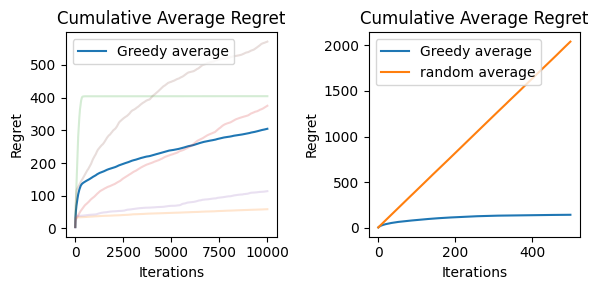

In [9]:
n_regret_logreg = np.array(n_regret_logreg)
n_regret_random = np.array(n_regret_random)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].plot(n_regret_logreg.mean(axis=0).cumsum(), label='Greedy average')
for i in range(n_runs):
    axes[0].plot(n_regret_logreg[i].cumsum(), alpha=0.2)
axes[0].set_title('Cumulative Average Regret')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Regret')
axes[0].legend()

# the same plot, but with random performance
axes[1].plot(n_regret_logreg.mean(axis=0)[:500].cumsum(), label='Greedy average')
axes[1].plot(n_regret_random.mean(axis=0)[:500].cumsum(), label='random average')
axes[1].set_title('Cumulative Average Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

plt.tight_layout()
plt.show()

# Nonlinear reward

To ensure the optimal action varies with context features, we integrate the context features $x$ with the action features $a$. Instead of fixed features $a$, define $a(x)$ so that action features dynamically interact with $x$: $a(x) = a + L(a) \cdot x$, where $L$ is the context-action weight vector.

So, in this setting, the reward score is linear in the $x, a(x)$ features:

$$P(y|x,a) = \frac{1}{1 + exp(-w_*^T \cdot [x, a(x)])}.$$

Such a reward structure represents a set of linear functions for a given $a$, but the overall reward structure, across different actions $a$, is nonlinear. Intuitively, Regularized Logistic regression should have trouble learning such rewards because weights $L(a)$ are never presented explicitly, and the parameterization of the policy shouldn't be able to capture these dependencies.

In [10]:
np.random.seed(123)
k = 20
n = 10000

nonlinear_env = SimulatorTorchWrapper(k=k, linear=False)
X = nonlinear_env.generate_batch(n)
A = np.random.choice(range(k), size=n)
Y, true_scores = nonlinear_env.generate_reward(A)

optimal_actions = true_scores.argmax(axis=1)
normalized_actions_scores = sigmoid(true_scores).sum(axis=0)

In the plot below, normalized scores (orange) show that over the whole population, there is an optimal action - action 4; nevertheless, optimal actions (blue) show that optimality given context $x$ varies.

Note: the scale of the normalized scores (orange) doesn't matter here.

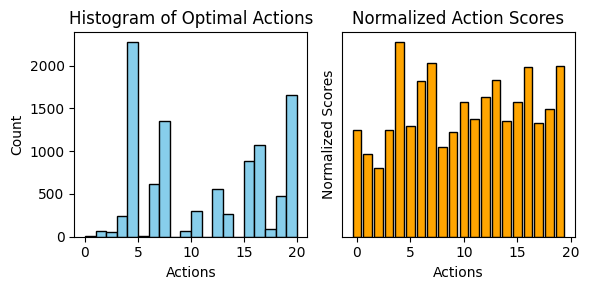

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].hist(optimal_actions, bins=range(0, k + 1), color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Optimal Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')

axes[1].bar(range(k), normalized_actions_scores, color='orange', edgecolor='black')
axes[1].set_title('Normalized Action Scores')
axes[1].set_xlabel('Actions')
axes[1].set_ylabel('Normalized Scores')
axes[1].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()

## Run single experiment

In [12]:
batch_size = 32
n_iter = 10000

d = nonlinear_env.d_x + nonlinear_env.d_a
params = {'temperature': 0.1, 'lr': 0.01}
policy = IncrementalGreedyAgent(d)

chosen_actions, optimal_actions, logreg_regret, random_regret = run_experiment_torch(nonlinear_env, policy, n_iter, batch_size, verbose=True)

      0/  10000 - mse params ------, mse scores: 7.8549, variance: ------
      1/  10000 - mse params ------, mse scores: 7.3746, variance: ------
      2/  10000 - mse params ------, mse scores: 8.7263, variance: ------
      3/  10000 - mse params ------, mse scores: 7.6201, variance: ------
      4/  10000 - mse params ------, mse scores: 12.2892, variance: ------
      5/  10000 - mse params ------, mse scores: 8.5350, variance: ------
      6/  10000 - mse params ------, mse scores: 8.4589, variance: ------
      7/  10000 - mse params ------, mse scores: 7.2837, variance: ------
      8/  10000 - mse params ------, mse scores: 6.9158, variance: ------
      9/  10000 - mse params ------, mse scores: 6.8621, variance: ------
     10/  10000 - mse params ------, mse scores: 6.9422, variance: ------
     11/  10000 - mse params ------, mse scores: 8.6489, variance: ------
     12/  10000 - mse params ------, mse scores: 9.2857, variance: ------
     13/  10000 - mse params ------, 

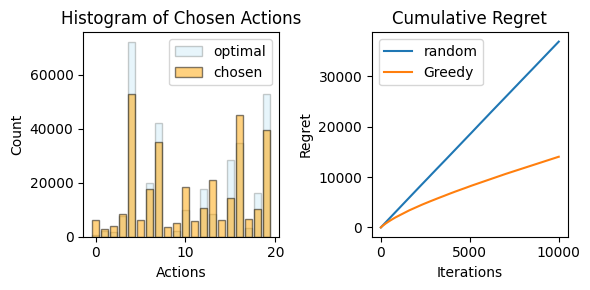

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].bar(range(k), optimal_actions, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), chosen_actions, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(np.array(random_regret).cumsum(), label='random')
axes[1].plot(np.array(logreg_regret).cumsum(), label='Greedy')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
batch_size = 32
n_iter = 10000

d = nonlinear_env.d_x + nonlinear_env.d_a
params = {'temperature': 1., 'lr': 0.01}
policy = IncrementalGreedyAgent(d)

chosen_actions, optimal_actions, logreg_regret, random_regret = run_experiment_torch(nonlinear_env, policy, n_iter, batch_size, verbose=True)

      0/  10000 - mse params ------, mse scores: 8.0436, variance: ------
      1/  10000 - mse params ------, mse scores: 8.6138, variance: ------
      2/  10000 - mse params ------, mse scores: 9.0775, variance: ------
      3/  10000 - mse params ------, mse scores: 6.4386, variance: ------
      4/  10000 - mse params ------, mse scores: 9.5680, variance: ------
      5/  10000 - mse params ------, mse scores: 8.4976, variance: ------
      6/  10000 - mse params ------, mse scores: 8.4294, variance: ------
      7/  10000 - mse params ------, mse scores: 8.5979, variance: ------
      8/  10000 - mse params ------, mse scores: 8.4471, variance: ------
      9/  10000 - mse params ------, mse scores: 9.3367, variance: ------
     10/  10000 - mse params ------, mse scores: 11.4436, variance: ------
     11/  10000 - mse params ------, mse scores: 9.1645, variance: ------
     12/  10000 - mse params ------, mse scores: 6.8434, variance: ------
     13/  10000 - mse params ------, 

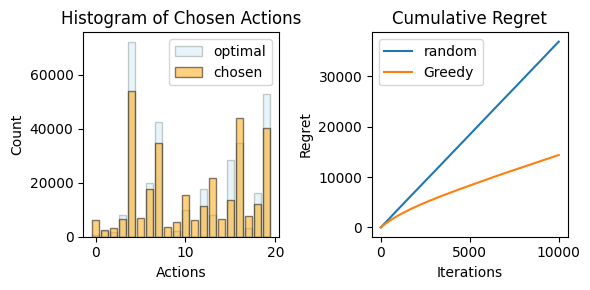

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].bar(range(k), optimal_actions, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), chosen_actions, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(np.array(random_regret).cumsum(), label='random')
axes[1].plot(np.array(logreg_regret).cumsum(), label='Greedy')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

plt.tight_layout()
plt.show()